# Assignment 9

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
import plotly.graph_objs as plotly  # for interactive plots

import tensorflow as tf
from tensorflow.keras.datasets import imdb

---
### Step 1: Data ingestion

In this lab, you'll train a <span style="color:chocolate">sentiment</span> classifier for movie reviews.

* The input is the text of a movie review;
* The output is the probability the input is a positive review.
* The target labels are binary, 0 for negative and 1 for positive.

The data includes 50,000 movie reviews on IMDB. The data comes pre-segmented into train and test splits. The [data loading function](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data) below also splits each input text into tokens (words), and maps the words to integer values. Each input is a sequence of integers corresponding to the words.

In [3]:
# read data
(X_train, Y_train), (X_test, Y_test) = imdb.load_data(path="imdb.npz",
                                                      num_words=None,
                                                      skip_top=0,
                                                      maxlen=None,
                                                      seed=113,
                                                      start_char=1,
                                                      oov_char=2,
                                                      index_from=3)

print("X_train.shape:", X_train.shape)
print("Y_train.shape:", Y_train.shape)
print("X_test.shape:", X_test.shape)
print("Y_test.shape:", Y_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train.shape: (25000,)
Y_train.shape: (25000,)
X_test.shape: (25000,)
Y_test.shape: (25000,)


---
### Step 2: Data preprocessing

Let's have a look at the first training example:

In [4]:
print('First training example data:', X_train[0])
print('First training example label:', Y_train[0])

First training example data: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
First t

As you can see, the first training example is a positive review. However, that sequence of integer IDs is hard to read.

The data loader provides a dictionary mapping words to IDs. Let's create a reverse index.


In [5]:
# The imdb dataset comes with an index mapping words to integers.
# In the index the words are ordered by frequency they occur.
index = imdb.get_word_index()

# Because we used index_from=3 (above), setting aside ids below 3 for special
# symbols, we need to add 3 to the index values.
index = dict([(key, value+3) for (key, value) in index.items()])

# Create a reverse index so we can lookup tokens assigned to each id.
reverse_index = dict([(value, key) for (key, value) in index.items()])
reverse_index[1] = '<START>'  # start of input
reverse_index[2] = '#'        # out-of-vocabulary (OOV)
reverse_index[3] = '<UNUSED>'

max_id = max(reverse_index.keys())
print('Largest ID:', max_id)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Largest ID: 88587


Note that our index (and reverse index) have <span style="color:chocolate">88,587</span> tokens. That's quite <span style="color:chocolate">a large vocabulary</span>!

Next, let's write a decoding function for our data.

In [6]:
def decode(token_ids):
  """Return a string with the decoded text given a list of token ids."""
  # Try looking up each id in the index, but return '#' (for OOV) if not found.
  tokens = [reverse_index.get(i, "#") for i in token_ids]

  # Connect the string tokens with a space.
  return ' '.join(tokens)

# Show the ids corresponding tokens in the first example.
print(X_train[0])
print(decode(X_train[0]))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
<START> this film was just brilliant

---
### Step 3: Exploratory Data Analysis (EDA)

### <span style="color:chocolate">Exercise 1:</span> Text lengths (10 points)

Using the training reviews data, answer the following questions:

1. What are the minimum, maximum, and mean lengths of positive and negative reviews?
2. Create a histogram to visualize the distribution of positive and negative review lengths. Make sure to provide a descriptive title and axis labels.

In [7]:
# YOUR CODE HERE

# Getting positive and negative indices
pos_indices = np.where(Y_train == 1)[0]
neg_indices = np.where(Y_train == 0)[0]

# Getting new np arrays for positive and negative reviews
X_train_pos = X_train[pos_indices]
X_train_neg = X_train[neg_indices]

# 1. Getting the minimum, maximum, and mean lengths of pos and neg reviews
min_len_pos = min([len(i) for i in X_train_pos])
max_len_pos = max([len(i) for i in X_train_pos])
mean_len_pos = sum([len(i) for i in X_train_pos]) / len(
    [len(i) for i in X_train_pos])

min_len_neg = min([len(i) for i in X_train_neg])
max_len_neg = max([len(i) for i in X_train_neg])
mean_len_neg = sum([len(i) for i in X_train_neg]) / len(
    [len(i) for i in X_train_neg])

print("1. Positive Reviews:")
print(" - Minimum length:", min_len_pos)
print(" - Maximum length:", max_len_pos)
print(" - Mean length:", mean_len_pos, '\n')
print("Negative Reviews:")
print(" - Minimum length:", min_len_neg)
print(" - Maximum length:", max_len_neg)
print(" - Mean length:", mean_len_neg)

1. Positive Reviews:
 - Minimum length: 13
 - Maximum length: 2494
 - Mean length: 241.56296 

Negative Reviews:
 - Minimum length: 11
 - Maximum length: 1571
 - Mean length: 235.86432


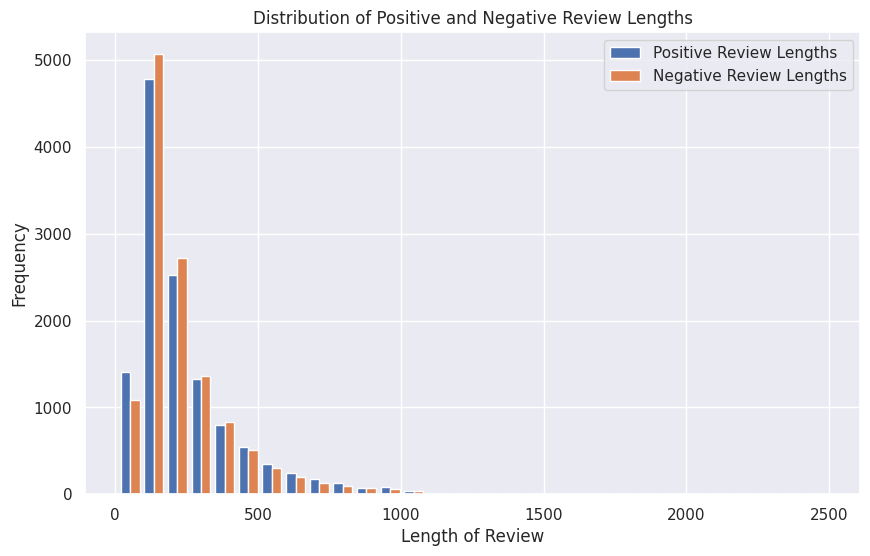

In [8]:
# Creating lengths for positive and negative reviews
X_train_pos_lengths = [len(i) for i in X_train_pos]
X_train_neg_lengths = [len(i) for i in X_train_neg]

# 2. Creating a histogram to visualize distribution of pos and neg review lens
plt.figure(figsize=(10, 6))
plt.hist((X_train_pos_lengths, X_train_neg_lengths), bins=30,
         label=("Positive Review Lengths", "Negative Review Lengths"))
plt.xlabel("Length of Review")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of Positive and Negative Review Lengths")

# Showing the plot
plt.show()

### <span style="color:chocolate">Exercise 2:</span> Token counts (10 points)

Using the training data, create a table listing the counts of positive and negative examples that contain each token provided below.

In [9]:
tokens = ['good', 'bad', 'amazing', 'boring', 'laugh', 'cry']
# YOUR CODE HERE

# Getting the tokens' indices
token_indices = {token: index[token] for token in tokens}

# Initializing counts
token_counts = {token: {"Positive": 0, "Negative": 0} for token in tokens}

# Getting the number of pos or neg reviews that each token is in
# (Since there are the same number of pos and neg reviews, this is ok)
for pos_rev, neg_rev in zip(X_train_pos, X_train_neg):
  for token in tokens:
    if token_indices[token] in pos_rev:
      token_counts[token]["Positive"] += 1
    if token_indices[token] in neg_rev:
      token_counts[token]["Negative"] += 1

# Getting a table of positive and negative examples for each token
token_counts_df = pd.DataFrame.from_dict(token_counts, orient='index')

token_counts_df

,Positive,Negative
good,4767,4849
bad,1491,4396
amazing,868,240
boring,301,1205
laugh,525,685
cry,231,114


---
### Step 4: Data preprocessing (cont'd)

As is clear from the review length histogram, the current representation of the review text is a variable-length array. Since fixed-length arrays are easier to work with in Tensorflow, you will add special padding tokens at the end of each review until they are all the same length. You will also truncate all training inputs to a specified length.

### <span style="color:chocolate">Exercise 3:</span> Reduced length and padding (10 points)

Fill in the <span style="color:green">NotImplemented</span> parts of the <span style="color:chocolate">truncate_pad_data()</span> function below by following these instructions:

1. Restrict the maximum number of tokens by truncating all reviews to a length of 300;
2. Append special padding tokens (value = 0) to the end of each review until all reviews are of the same length.

In [10]:
def truncate_pad_data(sequences, max_length):
    # Keras has a convenient utility for padding a sequence:
    # tf.keras.preprocessing.sequence.pad_sequences()
    # Also make sure you get a numpy array rather than an array of lists.

    padded_lists = tf.keras.preprocessing.sequence.pad_sequences(
        sequences, padding="post", truncating="post", maxlen=max_length)

    padded_data = np.array(padded_lists)
    return padded_data

# 1+ 2: Truncate and pad the training data
X_train_padded = truncate_pad_data(X_train, max_length=300)

# Check the padded output.
print('Length of X_train[0]:', len(X_train[0]))
print('Length of X_train_padded[0]:', len(X_train_padded[0]))
print(X_train_padded[0])

Length of X_train[0]: 218
Length of X_train_padded[0]: 300
[    1    14    22    16    43   530   973  1622  1385    65   458  4468
    66  3941     4   173    36   256     5    25   100    43   838   112
    50   670 22665     9    35   480   284     5   150     4   172   112
   167 21631   336   385    39     4   172  4536  1111    17   546    38
    13   447     4   192    50    16     6   147  2025    19    14    22
     4  1920  4613   469     4    22    71    87    12    16    43   530
    38    76    15    13  1247     4    22    17   515    17    12    16
   626    18 19193     5    62   386    12     8   316     8   106     5
     4  2223  5244    16   480    66  3785    33     4   130    12    16
    38   619     5    25   124    51    36   135    48    25  1415    33
     6    22    12   215    28    77    52     5    14   407    16    82
 10311     8     4   107   117  5952    15   256     4 31050     7  3766
     5   723    36    71    43   530   476    26   400   317    4

Next, you want to be able to limit the vocabulary size. Since the <span style="color:chocolate">truncate_pad_data()</span> function produces fixed-length sequences in a numpy matrix, one can use clever numpy indexing to efficiently replace all token ids larger than some value with the designated out-of-vocabulary (OOV) id.

### <span style="color:chocolate">Exercise 4:</span> Reduced vocabulary (10 points)

Fill in the <span style="color:green">NotImplemented</span> parts of the <span style="color:chocolate">limit_vocab()</span> function below by following these instructions:

1. Keep just token ids less than 1000, replacing all others with OOV.

In [11]:
def limit_vocab(sequences, max_token_id, oov_id=2):
  """Replace token ids greater than or equal to max_token_id with the oov_id."""
  # YOUR CODE HERE
  reduced_sequences = np.where(sequences >= max_token_id, oov_id, sequences)
  return reduced_sequences

# Reduce vocabulary to 1000 tokens.
X_train_reduced = limit_vocab(X_train_padded, max_token_id=1000)
print(X_train_reduced[0])

# Decode to see what this looks like in tokens. Note the '#' for OOVs.
print(decode(X_train_reduced[0]))

[  1  14  22  16  43 530 973   2   2  65 458   2  66   2   4 173  36 256
   5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2 336 385  39   4 172   2   2  17 546  38  13 447   4 192  50  16
   6 147   2  19  14  22   4   2   2 469   4  22  71  87  12  16  43 530
  38  76  15  13   2   4  22  17 515  17  12  16 626  18   2   5  62 386
  12   8 316   8 106   5   4   2   2  16 480  66   2  33   4 130  12  16
  38 619   5  25 124  51  36 135  48  25   2  33   6  22  12 215  28  77
  52   5  14 407  16  82   2   8   4 107 117   2  15 256   4   2   7   2
   5 723  36  71  43 530 476  26 400 317  46   7   4   2   2  13 104  88
   4 381  15 297  98  32   2  56  26 141   6 194   2  18   4 226  22  21
 134 476  26 480   5 144  30   2  18  51  36  28 224  92  25 104   4 226
  65  16  38   2  88  12  16 283   5  16   2 113 103  32  15  16   2  19
 178  32   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   

### <span style="color:chocolate">Exercise 5:</span> One-hot encoding (0 points)

The current feature representations are **sparse**. That is, one only keeps track of the token ids that are present in the input. A **one-hot** encoding replaces a value like 22 (corresponding to 'film') with an array with a single 1 at position 22 and zeros everywhere else. This will be very memory-inefficient, but we'll do it anyway for clarity.

To avoid any memory limitations, let's dramatically reduce both the number of token positions (review length) and the number of token ids (vocabulary).

The code below clips each review after 20 tokens and keeps only the first 1000 tokens.

In [12]:
# Keras has a util to create one-hot encodings.
X_train_padded = truncate_pad_data(X_train, max_length=20)
X_train_reduced = limit_vocab(X_train_padded, max_token_id=1000)
X_train_one_hot = tf.keras.utils.to_categorical(X_train_reduced)
print('X_train_one_hot shape:', X_train_one_hot.shape)

X_train_one_hot shape: (25000, 20, 1000)


Note the shape of the one-hot encoded features. For each of the 25000 training examples, you have a 20 x 1000 matrix. That is, for each of 20 token positions, you have a vector of 1000 elements containing a single 1 and 999 zeros.

You can think of these 1000-dimensional one-hot arrays as **embeddings**. Each token in the input has a 1000-dimensional representation. But because of the one-hot setup, the distance between each pair of tokens is the same ([1,0,0,...], [0,1,0,...], etc.). By contrast, learned embeddings result in meaningful distances between pairs of tokens. You'll get to that soon.

---
### Step 5: Modeling

### <span style="color:chocolate">Baseline model:</span> Logistic regression with one-hot encodings

You will start with something familiar -- logistic regression. Since your feature representation is in 2 dimensions (20 x 1000), you need to flatten it to pass it to Keras (remember you did this with the pixel data too). Try two strategies for flattening.

1. Flatten by *concatenating* (as you did with pixels), turning (20 x 1000) data into (20000,) data. The result is a separate feature for each token at each position;
2. Flatten by *averaging* over token positions, turning (20 x 1000) data into (1000,) data. The result is an array with average token counts, ignoring position.

In [13]:
def build_onehot_model(average_over_positions=False):
  """Build a tf.keras model for one-hot data."""
  # Clear session and remove randomness.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  model = tf.keras.Sequential()

  if average_over_positions:
    # This layer averages over the first dimension of the input by default.
    model.add(tf.keras.layers.GlobalAveragePooling1D())
  else:
    # Concatenate.
    model.add(tf.keras.layers.Flatten())

  model.add(tf.keras.layers.Dense(
      units=1,                     # output dim (for binary classification)
      activation="sigmoid"         # sigmoid activation for binary classification
  ))

  model.compile(loss='binary_crossentropy',   # this is a classification task
                optimizer='adam',             # fancy optimizer
                metrics=['accuracy'])

  return model

Now let's try fitting the model to your training data and check performance metrics on the validation data. But first, here's a function for plotting the learning curves given the training history object we get from Keras.

In [14]:
def plot_history(history):
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.xticks(range(0, len(history['loss'] + 1)))
  plt.plot(history['loss'], label="training", marker='o')
  plt.plot(history['val_loss'], label="validation", marker='o')
  plt.ylim(0,1)
  plt.legend()
  plt.show()

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5557 - loss: 0.6872 - val_accuracy: 0.6128 - val_loss: 0.6742
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6901 - loss: 0.6512 - val_accuracy: 0.6216 - val_loss: 0.6622
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7254 - loss: 0.6225 - val_accuracy: 0.6248 - val_loss: 0.6537
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7486 - loss: 0.5985 - val_accuracy: 0.6260 - val_loss: 0.6472
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7645 - loss: 0.5778 - val_accuracy: 0.6324 - val_loss: 0.6422


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 20000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          20,001 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 60,005 (234.40 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,004 (156.27 KB)

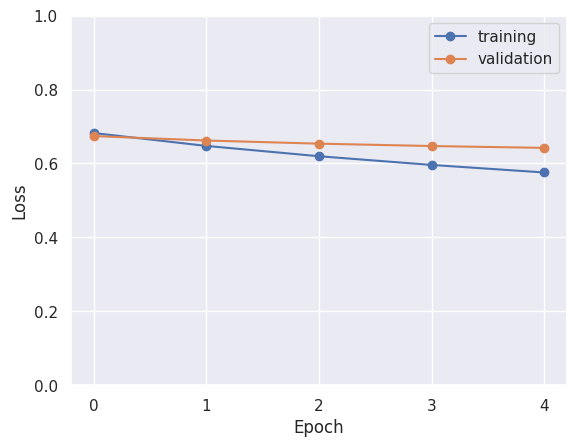

In [15]:
model1 = build_onehot_model()

# Fit the model.
history1 = model1.fit(
  x = X_train_one_hot,  # one-hot training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model1.summary()
# Convert the return value into a DataFrame so we can see the train loss
# and binary accuracy after every epoch.
history1 = pd.DataFrame(history1.history)
plot_history(history1)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5389 - loss: 0.6926 - val_accuracy: 0.5916 - val_loss: 0.6901
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6130 - loss: 0.6888 - val_accuracy: 0.6112 - val_loss: 0.6868
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6282 - loss: 0.6854 - val_accuracy: 0.6172 - val_loss: 0.6837
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6345 - loss: 0.6821 - val_accuracy: 0.6228 - val_loss: 0.6808
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6370 - loss: 0.6791 - val_accuracy: 0.6232 - val_loss: 0.6781


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ global_average_pooling1d             │ (None, 1000)                │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,001 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,005 (11.74 KB)

 Trainable params: 1,001 (3.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,004 (7.83 KB)

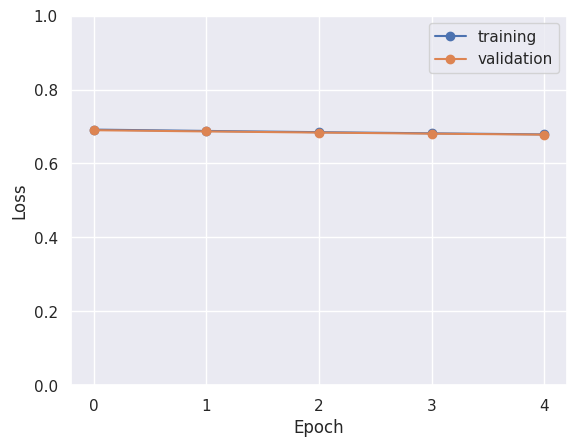

In [16]:
# Getting the averaged positions version
model1_2 = build_onehot_model(True)

# Fit the model.
history1_2 = model1_2.fit(
  x = X_train_one_hot,  # one-hot training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model1_2.summary()
# Convert the return value into a DataFrame so we can see the train loss
# and binary accuracy after every epoch.
history1_2 = pd.DataFrame(history1_2.history)
plot_history(history1_2)

### <span style="color:chocolate">Exercise 6:</span>  Comparing logistic regression models (20 points)

Train the one-hot model using both the concatenating and the averaging strategies and compare the results. Let's call these *LR-C* (Logistic Regression Concatenating) and *LR-A* (Logistic Regression Averaging). Then answer the following questions:

1. What are the final training and validation accuracies for LR-C and LR-A?
2. How many parameters are there in each model?
3. Would you say that either model is overfitting? Why or why not?
4. Briefly describe how LR-C differs from LR-A. How do you explain the relationship between their respective validation accuracy results?

*Written answer:*

1. For LR-C
 - The final training accuracy for LR-C was ~0.76.
 - The final validation accuracy for LR-C was ~0.63.

 For LR-A
 - The final training accuracy for LR-A was ~0.64.
 - The final validation accuracy for LR-A was ~0.62.

2. For LR-C
 - There are 60,005 total parameters in in the LR-C model. However, 40,004 of those parameters are from the Adam optimizer, which are internal to the optimizer itself and not trainable. Thus, removing those gives us 20,001 parameters (20,000 for the 2x20 one-hot encodings and 1 for the bias).

 For LR-A
 - There are 3,005 total parameters in the LR-A model. Once again, however, 2,004 of those are from the Adam optimizer, which are internal to the optimizer itself and not trainable. Removing those gives us 1,001 parameters parameters (1,000 for the average of each position and 1 for the bias).

3. I would not say that either model is overfitting too much. However, it does appear that model LR-C is more likely overfitting, as the final validation loss seems to be noticeably higher than the final training loss (the greater number of parameters could be one factor contributing to the overfitting). However, it almost seems that the models are underfitting instead, as the improvements to both training and validation accuracies are quite small after each epoch, and there still seems to be a lot of room for improvement. If we can change our hyperparameters at this step and see what changes we can induce, we might be able to get a better sense of whether either model is overfitting.

4. LR-C differs from LR-A primarily in the number of parameters that it trains and what they represent. In the LR-C model, each of the parameters represents a weight at each position of the one-hot encodings to the final (softmax) prediction of the review, which - because of how sparse it is - could potentially not give good validation accuracy. On the other hand, one benefit is that it keeps positional information intact for the inputted sentence. LR-A is instead a bag-of-words model, where taking the average (over the tokens) of each of the 1,000 dimensions loses the positional relevance of each word. In this model, each parameter represents a weight for the average across the tokens for that dimension, which could potentially make the model more generalizable and improve validation accuracy.

 Their respective validation accuracies do seem to reflect the above. Notably, while the validation accuracies for both models are roughly the same (~0.63 vs ~0.62), the training accuracy was much higher for LR-C, again contributing to the possibility that it generalizes less well.

### <span style="color:chocolate">Improvement over baseline:</span> Logistic regression with embeddings

Next, you will train a model that replaces one-hot representations of each token with learned embeddings.

The code below uses a Keras Embedding layer, which expects to receive a sparse (rather than one-hot) representation. That is, it expects a (padded) sequence of token ids; for each id, it looks up the corresponding embedding vector.

In [17]:
def build_embeddings_model(average_over_positions=False,
                           vocab_size=1000,
                           sequence_length=20,
                           embedding_dim=2):
  """Build a tf.keras model using embeddings."""
  # Clear session and remove randomness.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Embedding(
      input_dim=vocab_size,
      output_dim=embedding_dim,
      input_length=sequence_length)
  )

  if average_over_positions:
    # This layer averages over the first dimension of the input by default.
    model.add(tf.keras.layers.GlobalAveragePooling1D())
  else:
    # Concatenate.
    model.add(tf.keras.layers.Flatten())

  model.add(tf.keras.layers.Dense(
      units=1,                     # output dim (for binary classification)
      activation='sigmoid'         # apply the sigmoid function!
  ))

  model.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

  return model

You will train this model, this time using the averaging strategy instead of the concatenating strategy for handling the token sequence. You'll look up the embedding vectors for each token and average them to produce a single vector. Then, you'll use this averaged vector to train a logistic regression model to predict the binary label.

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5574 - loss: 0.6909 - val_accuracy: 0.6016 - val_loss: 0.6834
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6172 - loss: 0.6793 - val_accuracy: 0.6160 - val_loss: 0.6689
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6424 - loss: 0.6635 - val_accuracy: 0.6324 - val_loss: 0.6535
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6564 - loss: 0.6468 - val_accuracy: 0.6484 - val_loss: 0.6394
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6672 - loss: 0.6314 - val_accuracy: 0.6540 - val_loss: 0.6274


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 2)               │           2,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 2)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,011 (23.48 KB)

 Trainable params: 2,003 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,008 (15.66 KB)

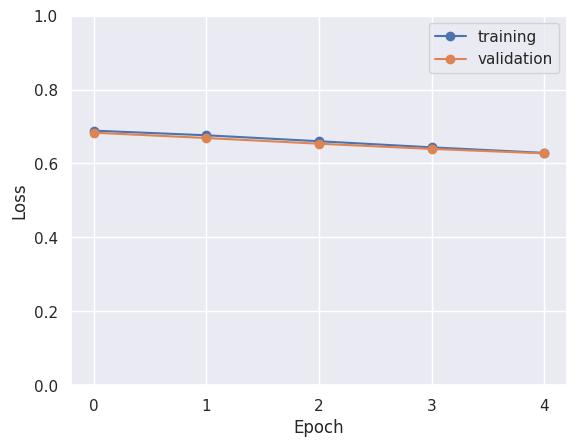

In [18]:
model2 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=2)
history2 = model2.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model2.summary()

history2 = pd.DataFrame(history2.history)
plot_history(history2)

### <span style="color:chocolate">Exercise 7:</span> Embedding size tuning (20 points)

Experiment with embedding sizes {2, 4, 8, 16, 32, 64}, while keeping other settings fixed and using the averaging strategy instead of the concatenating strategy. Then:

1. Construct a table showing the training and validation accuracies for each model after 5 training epochs;
2. Calculate the number of parameters in each model;
3. Analyze whether learned embeddings improve performance compared to one-hot encoding, and explain why this might be the case.

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5458 - loss: 0.6918 - val_accuracy: 0.5892 - val_loss: 0.6857
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6120 - loss: 0.6819 - val_accuracy: 0.6144 - val_loss: 0.6716
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6392 - loss: 0.6664 - val_accuracy: 0.6280 - val_loss: 0.6559
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6529 - loss: 0.6495 - val_accuracy: 0.6412 - val_loss: 0.6415
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6657 - loss: 0.6339 - val_accuracy: 0.6528 - val_loss: 0.6292


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 2)               │           2,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 2)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,011 (23.48 KB)

 Trainable params: 2,003 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,008 (15.66 KB)

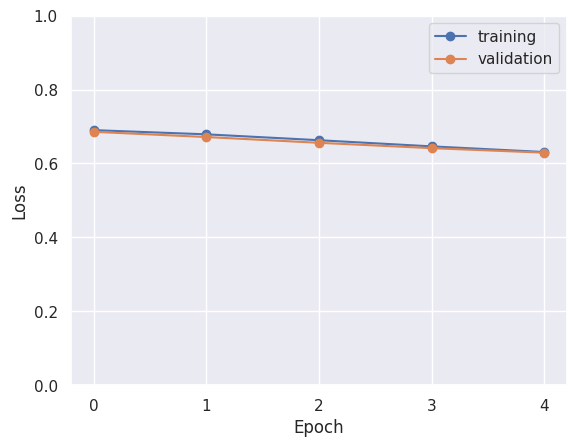

In [19]:
# Experimenting with embedding size 2
model2 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=2)
history2 = model2.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model2.summary()

history2 = pd.DataFrame(history2.history)
plot_history(history2)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5563 - loss: 0.6898 - val_accuracy: 0.6104 - val_loss: 0.6769
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6312 - loss: 0.6703 - val_accuracy: 0.6360 - val_loss: 0.6546
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6591 - loss: 0.6464 - val_accuracy: 0.6472 - val_loss: 0.6345
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6721 - loss: 0.6249 - val_accuracy: 0.6568 - val_loss: 0.6188
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6820 - loss: 0.6080 - val_accuracy: 0.6640 - val_loss: 0.6073


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 4)               │           4,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 4)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,017 (46.95 KB)

 Trainable params: 4,005 (15.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,012 (31.30 KB)

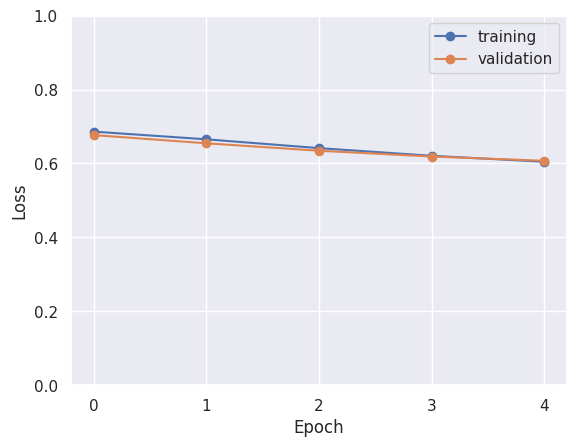

In [20]:
# Experimenting with embedding size 4
model4 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=4)
history4 = model4.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model4.summary()

history4 = pd.DataFrame(history4.history)
plot_history(history4)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5622 - loss: 0.6884 - val_accuracy: 0.6176 - val_loss: 0.6689
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6439 - loss: 0.6589 - val_accuracy: 0.6452 - val_loss: 0.6383
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6687 - loss: 0.6267 - val_accuracy: 0.6628 - val_loss: 0.6159
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6847 - loss: 0.6034 - val_accuracy: 0.6700 - val_loss: 0.6014
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6933 - loss: 0.5877 - val_accuracy: 0.6732 - val_loss: 0.5924


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 8)               │           8,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 8)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,029 (93.87 KB)

 Trainable params: 8,009 (31.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,020 (62.58 KB)

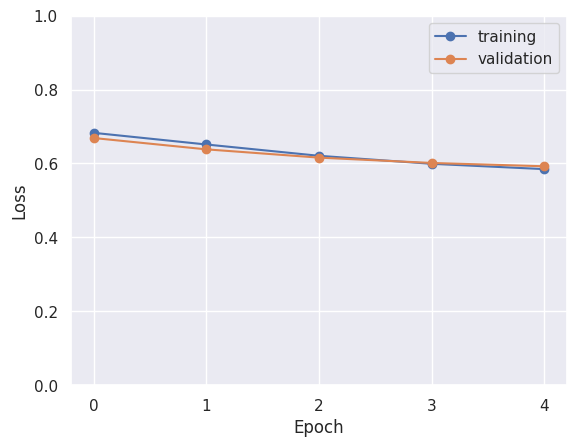

In [21]:
# Experimenting with embedding size 8
model8 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=8)
history8 = model8.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model8.summary()

history8 = pd.DataFrame(history8.history)
plot_history(history8)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5642 - loss: 0.6875 - val_accuracy: 0.6312 - val_loss: 0.6600
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6527 - loss: 0.6461 - val_accuracy: 0.6564 - val_loss: 0.6214
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6803 - loss: 0.6080 - val_accuracy: 0.6688 - val_loss: 0.6001
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6922 - loss: 0.5862 - val_accuracy: 0.6808 - val_loss: 0.5893
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6996 - loss: 0.5739 - val_accuracy: 0.6864 - val_loss: 0.5840


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 16)              │          16,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,053 (187.71 KB)

 Trainable params: 16,017 (62.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,036 (125.14 KB)

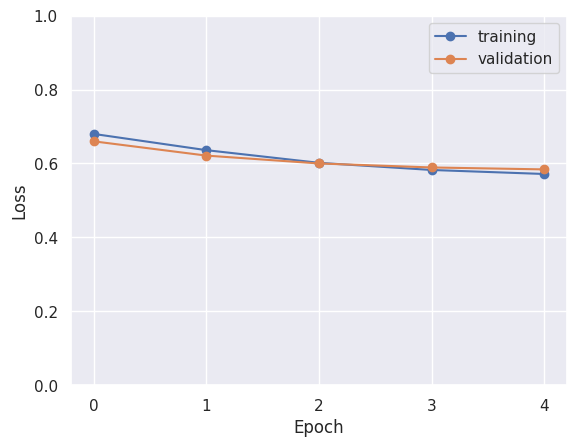

In [22]:
# Experimenting with embedding size 16
model16 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=16)
history16 = model16.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model16.summary()

history16 = pd.DataFrame(history16.history)
plot_history(history16)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5741 - loss: 0.6835 - val_accuracy: 0.6408 - val_loss: 0.6435
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6694 - loss: 0.6265 - val_accuracy: 0.6664 - val_loss: 0.6037
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6906 - loss: 0.5892 - val_accuracy: 0.6796 - val_loss: 0.5882
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6984 - loss: 0.5727 - val_accuracy: 0.6864 - val_loss: 0.5828
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7031 - loss: 0.5649 - val_accuracy: 0.6900 - val_loss: 0.5811


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 32)              │          32,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 96,101 (375.40 KB)

 Trainable params: 32,033 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,068 (250.27 KB)

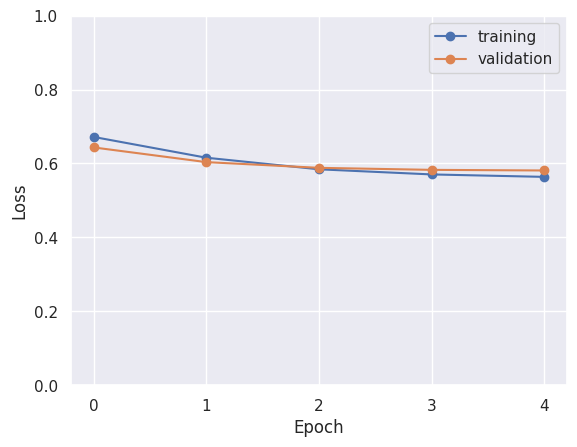

In [23]:
# Experimenting with embedding size 32
model32 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=32)
history32 = model32.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model32.summary()

history32 = pd.DataFrame(history32.history)
plot_history(history32)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5786 - loss: 0.6795 - val_accuracy: 0.6568 - val_loss: 0.6261
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6776 - loss: 0.6087 - val_accuracy: 0.6768 - val_loss: 0.5915
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6925 - loss: 0.5771 - val_accuracy: 0.6844 - val_loss: 0.5831
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6990 - loss: 0.5662 - val_accuracy: 0.6868 - val_loss: 0.5814
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6997 - loss: 0.5615 - val_accuracy: 0.6928 - val_loss: 0.5815


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 64)              │          64,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 192,197 (750.77 KB)

 Trainable params: 64,065 (250.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 128,132 (500.52 KB)

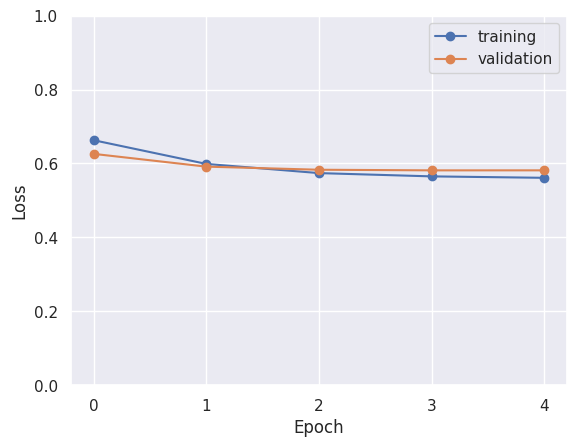

In [24]:
# Experimenting with embedding size 64
model64 = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=20,
                               embedding_dim=64)
history64 = model64.fit(
  x = X_train_reduced,  # our sparse padded training data
  y = Y_train,          # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

model64.summary()

history64 = pd.DataFrame(history64.history)
plot_history(history64)

In [25]:
# 1. Constructing a table showing the training and validation accuracies for
# each model after 5 training epochs:

# Getting the training and validation accuracies for each model
final_train_val_acc_hist2 = history2[['accuracy', 'val_accuracy']].iloc[-1]
final_train_val_acc_hist4 = history4[['accuracy', 'val_accuracy']].iloc[-1]
final_train_val_acc_hist8 = history8[['accuracy', 'val_accuracy']].iloc[-1]
final_train_val_acc_hist16 = history16[['accuracy', 'val_accuracy']].iloc[-1]
final_train_val_acc_hist32 = history32[['accuracy', 'val_accuracy']].iloc[-1]
final_train_val_acc_hist64 = history64[['accuracy', 'val_accuracy']].iloc[-1]

# Concatenating the accuracies together
final_train_val_acc = pd.concat([final_train_val_acc_hist2,
                                 final_train_val_acc_hist4,
                                 final_train_val_acc_hist8,
                                 final_train_val_acc_hist16,
                                 final_train_val_acc_hist32,
                                 final_train_val_acc_hist64], axis=1)

# Renaming the columns and rows and tranposing it for a better table
embedding_col_names = ['ES_2', 'ES_4', 'ES_8', 'ES_16', 'ES_32', 'ES_64']
final_train_val_acc.columns = embedding_col_names
final_train_val_acc = final_train_val_acc.T
final_train_val_acc.columns = ['Training Accuracy', 'Validation Accuracy']

print("1. Showing the training and validation accuracies for each model (with)")
print("their different embedding sizes (ES) after 5 training epochs:")
final_train_val_acc

1. Showing the training and validation accuracies for each model (with)
their different embedding sizes (ES) after 5 training epochs:


,Training Accuracy,Validation Accuracy
ES_2,0.663867,0.6528
ES_4,0.680489,0.6640
ES_8,0.692844,0.6732
ES_16,0.699956,0.6864
ES_32,0.703644,0.6900
ES_64,0.702000,0.6928


In [26]:
# 2. Calculating the number of parameters in each model
num_param_ES_2 = sum([tf.keras.backend.count_params(w) for w in model2.trainable_weights])
num_param_ES_4 = sum([tf.keras.backend.count_params(w) for w in model4.trainable_weights])
num_param_ES_8 = sum([tf.keras.backend.count_params(w) for w in model8.trainable_weights])
num_param_ES_16 = sum([tf.keras.backend.count_params(w) for w in model16.trainable_weights])
num_param_ES_32 = sum([tf.keras.backend.count_params(w) for w in model32.trainable_weights])
num_param_ES_64 = sum([tf.keras.backend.count_params(w) for w in model64.trainable_weights])

# Getting the number of parameters into a table
num_param_series = pd.DataFrame({"Number of Parameters": [num_param_ES_2,
                                                       num_param_ES_4,
                                                       num_param_ES_8,
                                                       num_param_ES_16,
                                                       num_param_ES_32,
                                                       num_param_ES_64]})

# Concatenating this dataframe with the previous dataframe
embedding_size_df = pd.concat([final_train_val_acc.reset_index(), num_param_series], axis=1)
embedding_size_df = embedding_size_df.set_index(['index'])

print("2. Calculating the number of parameters in each model:")
embedding_size_df

2. Calculating the number of parameters in each model:


,Training Accuracy,Validation Accuracy,Number of Parameters
index,,,
ES_2,0.663867,0.6528,2003
ES_4,0.680489,0.6640,4005
ES_8,0.692844,0.6732,8009
ES_16,0.699956,0.6864,16017
ES_32,0.703644,0.6900,32033
ES_64,0.702000,0.6928,64065


In [27]:
# 3. Analyzing whether learned embeddings improve performance compared to one-
# hot encodings and explaining why this might be the case

print("3. Accuracies of learned embeddings:")
print(embedding_size_df, '\n')

print("Final accuracies of concatenated one-hot encodings:")
print(" - Training accuracy:", history1['accuracy'].iloc[-1])
print(" - Validation accuracy:", history1['val_accuracy'].iloc[-1], '\n')
print("Final accuracies of averaged one-hot encodings:")
print(" - Training accuracy:", history1_2['accuracy'].iloc[-1])
print(" - Validation accuracy:", history1_2['val_accuracy'].iloc[-1])

3. Accuracies of learned embeddings:
       Training Accuracy  Validation Accuracy  Number of Parameters
index                                                              
ES_2            0.663867               0.6528                  2003
ES_4            0.680489               0.6640                  4005
ES_8            0.692844               0.6732                  8009
ES_16           0.699956               0.6864                 16017
ES_32           0.703644               0.6900                 32033
ES_64           0.702000               0.6928                 64065 

Final accuracies of concatenated one-hot encodings:
 - Training accuracy: 0.7600444555282593
 - Validation accuracy: 0.6323999762535095 

Final accuracies of averaged one-hot encodings:
 - Training accuracy: 0.6341333389282227
 - Validation accuracy: 0.623199999332428


*Written answer:*

1. As the size of the embedding dimensions increased, in general the training and validation accuracies both increased as well. The only caveat to that was that the training and validation accuracies for an embedding size of 32 versus 64 were very similar, signifying potentially minimal improvement. Nevertheless, the embeddings - with their ability to represent certain aspects of the words that may be incomprehensible to us - did seem to improve accuracy overall, especially for the validation data.

2. The number of trainable parameters in each model is simply the vocabulary size (1000) multiplied by the embedding dimension size (2, 4, 8, 16, 32, 64) plus the embedding dimension size (since that's the size after averaging over the vocabulary, which will be the input into the sigmoid function) plus 1 for the bias of the sigmoid activation. For example, for an embedding size of 64, we will have 1000 * 64 = 64000 parameters for the embedding layer. And after we go through the global averaging layer, we get 64 more parameters plus 1 for the bias to get 64065 trainable parameters in total. The non-trainable parameters are those in the optimizer, which tensorflow sets for us.

3. The learned embeddings definitely do seem to improve performance compared to the one-hot encodings. Even though the training accuracy may have been higher for the concatenated one-hot encoding model, the validation accuracies for both LR-C and LR-A were lower than even the lowest validation accuracy for the embedding model. With the highest embedding size (64), the validation accuracies was greater by ~6-7% (and it also had good generalization when comparing to the training accuracy). This is likely the case because in the one-hot encoding model, the vectors do not capture any word meanings or similarities between words, as the cosine of all respective pairs are 0 (since they are orthogonal to each other). In the learned embedding model, the embeddings themselves communicate word similarities (by comparing the angles of the words' embedding vectors), potentially allowing the model to associate certain words with positive or negative reviews. With even a single hidden layer to capture more complex relationships between the words, the model will likely perform even better, as it understands more "deeply" how the words are connected to one another and how that can potentially equate to a positive or negative review.


---

### Inspecting Learned Embeddings
You will now retrieve the learned embedding parameters from the trained model2 and plot the token embeddings.

The model layers in a Keras Sequential model are stored as a list and the embeddings are the first layer. You can use the <span style="color:chocolate">get_weights()</span> function to get a numpy array with the parameters.

In [28]:
# Display the model layers.
display(model2.layers)

# Retrieve the embeddings layer, which itself is wrapped in a list.
embeddings2 = model2.layers[0].get_weights()[0]
display(embeddings2.shape)

[<Embedding name=embedding, built=True>,
 <GlobalAveragePooling1D name=global_average_pooling1d, built=True>,
 <Dense name=dense, built=True>]

(1000, 2)

Now you'll use a fancy plotting tool called *plotly* to show the embeddings with hovertext so you can move your mouse over the points to see the corresponding tokens.

In [114]:
def plot_2d_embeddings(embeddings, id_start=1, count=100):
  # Get 1st and 2nd embedding dims for the desired tokens.
  x1 = embeddings[id_start:id_start+count, 0]
  x2 = embeddings[id_start:id_start+count, 1]

  # Get the corresponding words from the reverse index (for labeling).
  tokens = [reverse_index[i] for i in range(id_start, id_start+count)]

  # Plot with the plotly library.
  data = plotly.Scatter(x=x1, y=x2, text=tokens,
                        mode='markers', textposition='bottom left',
                        hoverinfo='text')
  fig = plotly.Figure(data=[data],
                      layout=plotly.Layout(title="Word Embeddings",
                                           hovermode='closest'))
  fig.show()

# Very frequent tokens tend to be more syntactic than semantic, so let's plot
# some rarer words.
plot_2d_embeddings(embeddings2, id_start=500, count=500)

### <span style="color:chocolate">Exercise 8:</span> Interpreting embeddings (20 points)

Notice that the 2-D embeddings fall in a narrow diagonal band. Answer the following questions:

1. Have the learned embeddings separated positive and negative words? What is the most negative word? Does this make sense?
2. Give 2 examples of words that seem to have surprising embedding values and try to explain their positions. For example, what's going on with the tokens '7', '8', and '9'? What are two other surprising results?
3. The embedding for 'crazy' is very close to (0,0). Explain what this means in terms of the model's output.
4. Can you explain what you think the 2 learned embedding dimensions mean, if anything?

YOUR ANSWER HERE

1. From the dimensions above, it does appear that the learned embeddings separated positive and negative words. Notably, the most negative word is "horrible," which most people would likely associate with a negative review. The most positive word, on the other hand, is "enjoyed," which also makes a lot of sense, as there's a positive connotation associated with that word, and it's difficult to put that word in a negative context (e.g., one might write "did not enjoy," which doesn't use the word "enjoyed" directly). Some other negative words are "ridiculous", "crap", or "poorly", whereas some other positive words are "favorite", "brilliant", or "greatest."

2. Two examples of words with surprising embedding values are "wonder" (token 594) and "thinking" (token 536). Specifically, as we can see below, their embeddings are much closer to the negative words than the positive words, which is somewhat surprising. "Wonder" as an adjective generally has a positive connotation, so it's interesting to see it lean negative. One potential reason could be that the word is used as a verb (e.g., "I wonder...") which might be present in more negative reviews. "Thinking" actually seems to be even more negative, which is also surprising as it generally has a neutral or even positive tone (e.g., "He's thinking about something..."). One reason this word might be so negative here could be that the reviews are suggesting reasons as to why something happened in the movie (i.e., "I'm thinking that the director did..."), which normally comes up when there's something in the movie the reviewer did not agree with.

 In terms of what's going on with tokens 7, 8, and 9, each of them definitely has a positive -- 7 ("of") and 9 ("is") -- or negative -- 8 ("to") -- lean. And while this is somewhat surprising as those words are neutral by themselves, the fact that they are so common could potentially make them lean in a certain direction. Furthermore, perhaps in these set of reviews, "of" and "is" happen to be associated with more positive words, whereas "to" happens to be associated with more negative words. Simply because of how common these words are, I would not definitively say that they are positive or negative based on their embeddings.

 If we instead want to know what's going on with the token **strings** of '7', '8', and '9', we see in the code below that they are all leaning positive (though interestingly enough, '9' seems to be the least positive). Since these are all ratings for above average reviews, it does make some sense that they lean positive. However, it's still interesting to see that they're not as positive as some of the words we saw previously.

3. Looking at our code below, the embedding for "crazy" is pretty close to (0, 0). This probably means that "crazy" is being used in both positive and negative reviews, and it doesn't associate strongly with either. For example, a "crazy good movie" review would be positive, whereas a "crazy bad movie" review would be negative. Therefore, this word seems to contribute quite little to classification, likely because there is no clear pattern for this word in the reviews.

4. It is somewhat difficult to explain what the 2 learned embedding dimensions mean, as it's a pretty narrow diagonal line across the line y = x, and the narrowness almost makes it appear that there's only one dimension. One likely hypothesis is that the dimensions just represent positive or negative sentiment, and the greater it is in one direction would make a word more positive, and the greater it is in the other direction would make a word more negative. Another idea could be that one of the dimensions relates to context and how strongly it associates with other positive or negative words, so the more it appears with other positive or negative words, the more closely in that direction it will be. Overall, however, the model doesn't seem to use the full capacity of the embedding space, and perhaps utilizing more than just the narrow diagonal line could help with the classification. Additionally, the dimensions themselves may not be independent (as their high correlation suggests), which means that going in one direction on either dimension equates to going that respective direction in the other dimension. If we had more data, or if we increased the number of embedding dimensions, we may be able to capture more nuanced relationships between words, which will also likely help our model classify more precisely.

In [115]:
# 1. Embeddings of positive and negative words
list_pos_words = ['enjoyed', 'favorite', 'brilliant', 'greatest']
list_neg_words = ['horrible', 'ridiculous', 'crap', 'poorly']

# Creating a function to print out words, their tokens, and their embeddings
def print_token_embeddings(word_list):
  for word in word_list:
    print(" - \"" + word + "\" (token " + str(index[word]) +
          ") with embedding vector:", embeddings2[index[word]])

print("1. Positive words:")
print_token_embeddings(list_pos_words)

print("\nNegative words:")
print_token_embeddings(list_neg_words)

1. Positive words:
 - "enjoyed" (token 510) with embedding vector: [-1.0376447 -0.9457622]
 - "favorite" (token 514) with embedding vector: [-0.9226164 -0.8919092]
 - "brilliant" (token 530) with embedding vector: [-0.8308313  -0.82110995]
 - "greatest" (token 833) with embedding vector: [-0.78959686 -0.69507724]

Negative words:
 - "horrible" (token 527) with embedding vector: [1.1018462 1.0289779]
 - "ridiculous" (token 647) with embedding vector: [0.8833081  0.73808086]
 - "crap" (token 595) with embedding vector: [0.76068604 0.71406037]
 - "poorly" (token 862) with embedding vector: [0.78477794 0.6996618 ]


In [155]:
# 2. Analyzing tokens with surprising embedding values and tokens 7, 8, and 9

# Getting two surprising embedding results
surprising_word_embeddings = ['wonder', 'thinking']
print("2. Surprising word embeddings:")
print_token_embeddings(surprising_word_embeddings)

# Getting embeddings for and decoding tokens 7, 8, and 9
print("\nGetting embeddings for and decoding tokens 7, 8, and 9:")
for i in range(7, 10):
  print(" - token " + str(i), "(\""+ decode([i]) + "\") with embedding vector:",
        embeddings2[i])

# Analyzing the tokens for strings '7', '8', and '9'
print("\nGetting embeddings for token strings '7', '8', and '9':")
print_token_embeddings(['7', '8', '9'])

2. Surprising word embeddings:
 - "wonder" (token 594) with embedding vector: [0.29050997 0.19591455]
 - "thinking" (token 536) with embedding vector: [0.4903511  0.44749454]

Getting embeddings for and decoding tokens 7, 8, and 9:
 - token 7 ("of") with embedding vector: [-0.31486222 -0.2883284 ]
 - token 8 ("to") with embedding vector: [0.49166232 0.48375633]
 - token 9 ("is") with embedding vector: [-0.5288227 -0.5106619]

Getting embeddings for token strings '7', '8', and '9':
 - "7" (token 693) with embedding vector: [-0.24144451 -0.2155702 ]
 - "8" (token 709) with embedding vector: [-0.3292756 -0.3923485]
 - "9" (token 790) with embedding vector: [-0.13812828 -0.10766541]


In [107]:
# 3. Getting the embedding for "crazy"
print("3. Getting the embedding for 'crazy':")
print_token_embeddings(['crazy'])

3. Getting the embedding for 'crazy':
 - "crazy" (token 932) with embedding vector: [0.10623784 0.14619088]


----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

More data and bigger models

Remember how you limited your input sequences to 20 tokens and 1000 vocabulary entries? Let's see how well you can do using more data and bigger models (more parameters).

Using pieces of code from above, set up and train a model to achieve at least 80% accuracy on both training and validation data. Ensure the following elements are included:

1. Truncate and pad input to the desired length;
2. Limit the vocabulary to the desired size;
3. Set up a model using embeddings;
4. Use the averaging strategy rather than the concatenating strategy;
5. Add additional layer(s) after the GlobalAveragePooling1D layer and before the output layer;
6. Evaluate the model's performance on the test data and comment on its generalization performance. Hint: remember to apply the same preprocessing to the test data. Use the <span style="color:chocolate">model.evaluate()</span> function for the final evaluation.

In [127]:
# YOUR CODE HERE

# 1. Truncating and padding input to a token length of 500
X_train_padded_2 = truncate_pad_data(X_train, max_length=500)

print("1. Truncating and padding input to a length of 500, since that's when")
print("the number of reviews decrease dramatically, as show by our histogram")
print("above.")
print(" - First entry in X_train_padded_2:")
print(X_train_padded_2[0])
print(" - Shape of first entry in X_train_padded_2:",
      X_train_padded_2[0].shape)

1. Truncating and padding input to a length of 500, since that's when
the number of reviews decrease dramatically, as show by our histogram
above.
 - First entry in X_train_padded_2:
[    1    14    22    16    43   530   973  1622  1385    65   458  4468
    66  3941     4   173    36   256     5    25   100    43   838   112
    50   670 22665     9    35   480   284     5   150     4   172   112
   167 21631   336   385    39     4   172  4536  1111    17   546    38
    13   447     4   192    50    16     6   147  2025    19    14    22
     4  1920  4613   469     4    22    71    87    12    16    43   530
    38    76    15    13  1247     4    22    17   515    17    12    16
   626    18 19193     5    62   386    12     8   316     8   106     5
     4  2223  5244    16   480    66  3785    33     4   130    12    16
    38   619     5    25   124    51    36   135    48    25  1415    33
     6    22    12   215    28    77    52     5    14   407    16    82
 10311     8  

In [128]:
# 2. Limiting the vocabulary to a size of 2,000
X_train_reduced_2 = limit_vocab(X_train_padded_2, max_token_id=2000)

print("2. Limiting the vocabulary to a size of 2,000, since a larger vocab")
print("should mean more precision.")
print(" - First entry in X_train_reduced_2:")
print(X_train_reduced_2[0])
print(" - Shape of first entry in X_train_reduced_2:",
      X_train_reduced_2[0].shape)

2. Limiting the vocabulary to a size of 2,000, since a larger vocab
should mean more precision.
 - First entry in X_train_reduced_2:
[   1   14   22   16   43  530  973 1622 1385   65  458    2   66    2
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172    2 1111   17  546   38   13  447    4  192   50   16    6  147
    2   19   14   22    4 1920    2  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4    2
    2   16  480   66    2   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117    2   15  256
    4    2    7    2    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
    2   56   26

In [129]:
# 3-5. Setting up a model using embeddings, using an averaging strategy, and
# adding an additional layer after the GlobalAveragePooling1D layer
def build_embeddings_model(vocab_size=2000,
                           sequence_length=500,
                           embedding_dim=64):

  # Clear session and remove randomness.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Embedding(
      input_dim=vocab_size,
      output_dim=embedding_dim,
      input_length=sequence_length)
  )

  # Averaging layer
  model.add(tf.keras.layers.GlobalAveragePooling1D())

  # Dense layer (dimension 16)
  model.add(tf.keras.layers.Dense(16, activation='relu'))

  # Output layer
  model.add(tf.keras.layers.Dense(
      units=1,                     # output dim (for binary classification)
      activation='sigmoid'         # apply the sigmoid function!
  ))

  model.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

  return model

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5247 - loss: 0.6893 - val_accuracy: 0.6920 - val_loss: 0.6424
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.6709 - loss: 0.6092 - val_accuracy: 0.8292 - val_loss: 0.4587
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8114 - loss: 0.4432 - val_accuracy: 0.8496 - val_loss: 0.3849
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8367 - loss: 0.3809 - val_accuracy: 0.8560 - val_loss: 0.3567
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8516 - loss: 0.3500 - val_accuracy: 0.8608 - val_loss: 0.3434


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 500, 64)             │         128,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 387,173 (1.48 MB)

 Trainable params: 129,057 (504.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 258,116 (1008.27 KB)

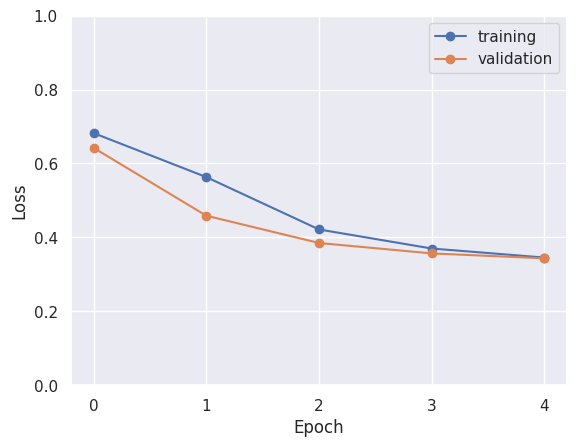

In [132]:
# Getting the improved model (model_i)
model_i = build_embeddings_model(vocab_size=2000,
                               sequence_length=500,
                               embedding_dim=64)
history_i = model_i.fit(
  x = X_train_reduced_2,  # our sparse padded training data
  y = Y_train,            # corresponding binary labels
  epochs=5,               # number of passes through the training data
  batch_size=64,          # mini-batch size
  validation_split=0.1,   # use a fraction of the examples for validation
  verbose=1               # display some progress output during training
  )

model_i.summary()

history_i = pd.DataFrame(history_i.history)
plot_history(history_i)

In [140]:
# 6. Evaluating the model's performance on the test data

# Truncating and padding input to a token length of 500 and limiting vocabulary
# to a size of 2,000 for X_test
X_test_padded_2 = truncate_pad_data(X_test, max_length=500)
X_test_reduced_2 = limit_vocab(X_test_padded_2, max_token_id=2000)

print("We must truncate and pad the input, along with limiting the vocabulary")
print("size for X_test as well as X_train because we 1) we want to make sure")
print("the dimensions fit with our ML model, and 2) the OOV words are")
print("represented properly in X_test. To double-check that X_test_reduced_2")
print("looks correct:\n")
print(" - First entry in X_test_reduced_2:")
print(X_test_reduced_2[0])
print(" - Shape of first entry in X_test_reduced_2:",
      X_test_reduced_2[0].shape)

We must truncate and pad the input, along with limiting the vocabulary
size for X_test as well as X_train because we 1) we want to make sure
the dimensions fit with our ML model, and 2) the OOV words are
represented properly in X_test. To double-check that X_test_reduced_2
looks correct:

 - First entry in X_test_reduced_2:
[   1  591  202   14   31    6  717   10   10    2    2    5    4  360
    7    4  177    2  394  354    4  123    9 1035 1035 1035   10   10
   13   92  124   89  488    2  100   28 1668   14   31   23   27    2
   29  220  468    8  124   14  286  170    8  157   46    5   27  239
   16  179    2   38   32   25    2  451  202   14    6  717    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0

In [154]:
# Using model.evaluate() for the final evalution
test_results = model_i.evaluate(X_test_reduced_2, Y_test)
print('\nTest Acc. {:.2f}%'.format(test_results[1]*100))

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8699 - loss: 0.3301

Test Acc. 86.78%


Commenting on the generalization performance of the improved model: Overall, the model seems to generalize really well to the test data. This isn't too surprising, as our validation data already showed that our model generalizes pretty well. One reason this might be the case is because we have that OOV token embedding, which allows for words that are not in our vocabulary to be represented.

In terms of how well our model did overall, as we see from above, we easily achieved above 80% for the training, validation, and test accuracies. This is likely because of the following factors:
1. The greater max length of our tokens (500) gave our model more chance to recognize and accurately classify longer sentences
2. The greater vocab (2000) allowed our model to be more adept at recognizing different words by creating embedding vectors for them
3. The greater embedding size (64) allowed more dimensions with the words, allowing our model to relate more closely in certain ways
4. We used a hidden layer (with 16 units), which added more nuance to our model and allowed it to recognize more patterns than just the embedding layer (perhaps with how certain tokens/words are combined)